In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from Logistic import Logistic_Regression

In [3]:
def create_data(n_samples_per_class=500, device="cpu"):
    X_class0 = torch.randn(n_samples_per_class, 2, device=device) + torch.tensor([1.0, -1.0], device=device)
    X_class1 = torch.randn(n_samples_per_class, 2, device=device) + torch.tensor([-1.0, 1.0], device=device)

    X = torch.cat([X_class0, X_class1], dim=0)   # (2n, 2)
    y = torch.cat([
        torch.zeros(n_samples_per_class, dtype=torch.float32, device=device),
        torch.ones(n_samples_per_class, dtype=torch.float32, device=device)
    ], dim=0).unsqueeze(1)   # (2n,1)

    perm = torch.randperm(X.shape[0], device=device)
    split = int(0.6 * X.shape[0])

    train_set = perm[:split]
    test_set = perm[split:]

    return X, y, train_set, test_set

# Logistic

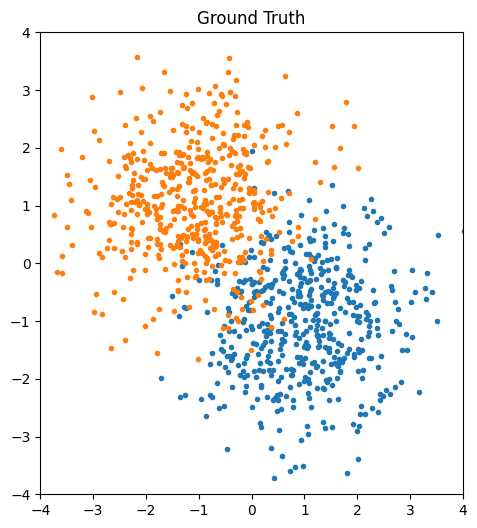

In [4]:
X, y, train_set, test_set = create_data()
X_np = X.cpu().numpy()
y_np = y.cpu().numpy().squeeze()

# Ground Truth
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], marker=".")
plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], marker=".")

In [5]:
logistic = Logistic_Regression()
logistic.train(X[train_set], y[train_set], iterations=500, lr=0.1)

y_pred = logistic.predict(X)          # (n,1)
y_pred_np = y_pred.cpu().numpy().squeeze()

acc = (y_pred[test_set] == y[test_set]).float().mean().item()
print(f"Accuracy = {100 * acc:.2f}%")

[iter 10] loss:0.7204628586769104
[iter 20] loss:0.5558558106422424
[iter 30] loss:0.4543423354625702
[iter 40] loss:0.38819754123687744
[iter 50] loss:0.34263601899147034
[iter 60] loss:0.30968281626701355
[iter 70] loss:0.2848983705043793
[iter 80] loss:0.2656781077384949
[iter 90] loss:0.2504175901412964
[iter 100] loss:0.23807424306869507
[iter 110] loss:0.2279413789510727
[iter 120] loss:0.2195197492837906
[iter 130] loss:0.21244964003562927
[iter 140] loss:0.20646056532859802
[iter 150] loss:0.20134979486465454
[iter 160] loss:0.19695983827114105
[iter 170] loss:0.1931687444448471
[iter 180] loss:0.1898791491985321
[iter 190] loss:0.18701253831386566
[iter 200] loss:0.18450358510017395
[iter 210] loss:0.18230408430099487
[iter 220] loss:0.18036845326423645
[iter 230] loss:0.17866027355194092
[iter 240] loss:0.17715026438236237
[iter 250] loss:0.17581400275230408
[iter 260] loss:0.1746266633272171
[iter 270] loss:0.17357157170772552
[iter 280] loss:0.17263203859329224
[iter 290] l

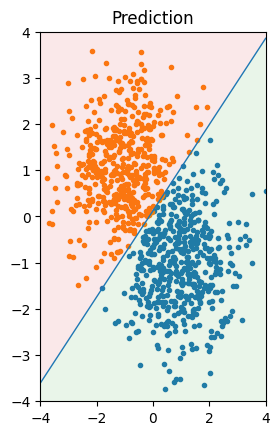

In [6]:
plt.subplot(1, 2, 2)
plt.title("Prediction")
plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.scatter(X_np[y_pred_np == 0, 0], X_np[y_pred_np == 0, 1], marker=".")
plt.scatter(X_np[y_pred_np == 1, 0], X_np[y_pred_np == 1, 1], marker=".")

w_hat = logistic.w_hat.detach().cpu().numpy().squeeze()  # (3,)

# w_hat = [w1, w2, b]
a = -w_hat[0] / w_hat[1]
b = -w_hat[2] / w_hat[1]

line_x = np.linspace(-4, 4, 400)
line_y = a * line_x + b

plt.plot(line_x, line_y, lw=1)

plt.fill_between(line_x, -4, line_y, alpha=0.1)
plt.fill_between(line_x, +4, line_y, alpha=0.1)

plt.show()